In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [2]:
omega = 1.8

feature_vec_len = 8
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

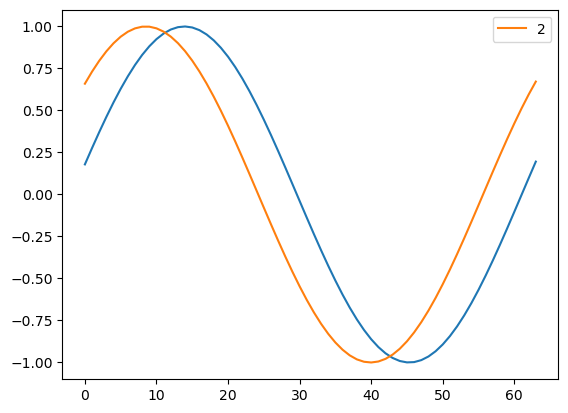

In [3]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [4]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(time_horizon - dt)

    is_included = np.random.random(positions) > inclusion_prob
    for idx, included in zip(range(positions), is_included):
        sample.append((
            idx/positions,
            included*1.0,
            values[time_stamp, idx] * included,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_stamp + dt, idx],
        ))

    return (
        torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [5]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)

In [6]:
fe_model = feature_encoder()
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample[0])

/tmp/ipykernel_49658/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


tensor([[ 0.1105, -0.0764, -0.0582,  0.1515, -0.0800,  0.0565, -0.0801, -0.0816],
        [ 0.1106, -0.0764, -0.0585,  0.1516, -0.0795,  0.0564, -0.0800, -0.0822],
        [ 0.1187, -0.1067, -0.0461,  0.1777, -0.1062,  0.0722, -0.0743, -0.1043],
        [ 0.1216, -0.1023, -0.0468,  0.1775, -0.1052,  0.0692, -0.0777, -0.1021],
        [ 0.1243, -0.0977, -0.0476,  0.1773, -0.1041,  0.0662, -0.0810, -0.0996],
        [ 0.1270, -0.0929, -0.0485,  0.1773, -0.1029,  0.0630, -0.0842, -0.0969],
        [ 0.1110, -0.0761, -0.0598,  0.1519, -0.0771,  0.0560, -0.0792, -0.0853],
        [ 0.1318, -0.0829, -0.0507,  0.1774, -0.1005,  0.0564, -0.0901, -0.0909],
        [ 0.1111, -0.0760, -0.0603,  0.1521, -0.0762,  0.0558, -0.0788, -0.0865],
        [ 0.1358, -0.0730, -0.0533,  0.1778, -0.0980,  0.0497, -0.0950, -0.0846],
        [ 0.1112, -0.0759, -0.0608,  0.1523, -0.0753,  0.0555, -0.0785, -0.0877],
        [ 0.1389, -0.0636, -0.0560,  0.1786, -0.0956,  0.0433, -0.0988, -0.0782],
        [ 0.1113

In [16]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = 16
        edge_params_shape = values.shape[1]**2
        #self.fe = feature_encoder()
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)
        self.neurons = 1
        self.double_neurons = self.neurons * 2
        self.trunk_in = 1
        self.output_neurons = 1

        self.l1 = tgnn.GAT(
            in_channels=3,#feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.branch = self.branch_network()
        self.trunk = self.trunk_network()

    def branch_network(self):
        branch = nn.Sequential(
            nn.Linear(self.gnn_out_ch, self.double_neurons),
            nn.ReLU(),
            nn.Linear(self.double_neurons,self.output_neurons),
        )
        return branch
        
    def trunk_network(self):
        trunk=nn.Sequential(
            nn.Linear(self.trunk_in, self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.output_neurons),
        )
        return trunk

    def forward(self, dt, nodes, edges):
        encoded_features = nodes#self.fe(nodes)

        g_output = self.l1(encoded_features, edges, edge_attr=self.edge_params)

        x1 = self.branch(g_output)
        x2 = self.trunk(dt).repeat(x1.shape[0], 1)

        x = torch.einsum("bi, bi->b", x1,x2)
        x = torch.unsqueeze(x,1)
        return x



In [17]:
model = gnn_model()

In [18]:
model(
    torch._cast_Float(torch.randint(1,16, (1,))),
    sample[0],
    sample[1],
).shape

torch.Size([64, 1])

In [19]:
NUM_TR_STEPS = 1024*32
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-2,)
loss_fn = nn.MSELoss()

for i in range(NUM_TR_STEPS):
    rand_dt = torch.randint(1,16, (1,))
    sample = get_sample(values, rand_dt.item())

    y_hat = model(
        torch._cast_Float(rand_dt),
        sample[0],
        sample[1],
    )

    loss = loss_fn(sample[2][:,-1:], y_hat[:,-1:])
    
    # check if this is correct place for zero grad
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T
        loss_t_dt.append(l_dt.detach())
        print(f"l_dt:{torch.mean(l_dt)}")



/tmp/ipykernel_49658/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


l_dt:0.5411603450775146
l_dt:0.5059276223182678
l_dt:0.5051097273826599
l_dt:0.49847927689552307
l_dt:0.491653174161911
l_dt:0.49160003662109375
l_dt:0.49628692865371704
l_dt:0.4967895746231079
l_dt:0.5075280070304871
l_dt:0.4923064708709717
l_dt:0.5079437494277954
l_dt:0.49494925141334534
l_dt:0.49645644426345825
l_dt:0.49401426315307617
l_dt:0.49165093898773193
l_dt:0.5018317699432373
l_dt:0.509526789188385
l_dt:0.498679518699646
l_dt:0.49805861711502075
l_dt:0.49109941720962524
l_dt:0.5033301115036011
l_dt:0.49161142110824585
l_dt:0.508250892162323
l_dt:0.4942812919616699
l_dt:0.4909961223602295
l_dt:0.5052323341369629
l_dt:0.49109965562820435
l_dt:0.5073840022087097
l_dt:0.49674129486083984
l_dt:0.4924803078174591
l_dt:0.4927046298980713
l_dt:0.5025841593742371
l_dt:0.50227952003479
l_dt:0.5079243183135986
l_dt:0.49918609857559204
l_dt:0.49429020285606384
l_dt:0.49995705485343933
l_dt:0.5044269561767578
l_dt:0.5079396367073059
l_dt:0.49166780710220337
l_dt:0.49156296253204346
l_dt:

KeyboardInterrupt: 

In [39]:
torch.mean((
    #y_hat[:,-1:] - sample[2][:,-1:])**2)
    sample[0][:,-1:] - sample[2][:,-1:])**2)

tensor(0.2666)

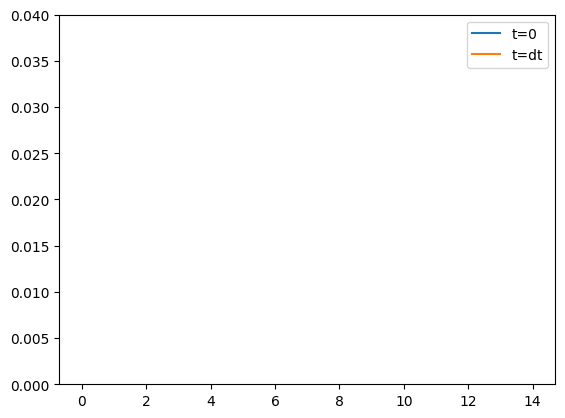

In [40]:
mean_over = 20
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array([torch.mean(x).item() for x in loss_t_dt])
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.04)
plt.show()

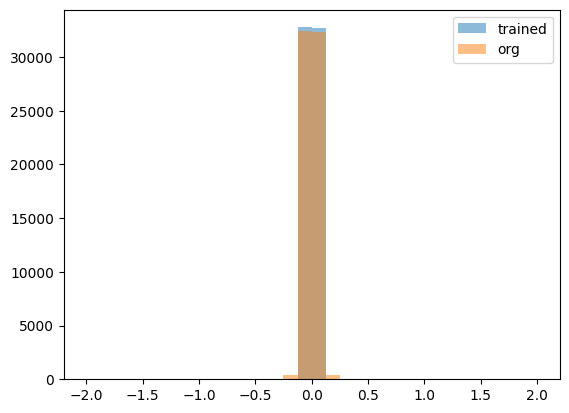

In [41]:
plt.hist(model.edge_params.detach().flatten(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

In [44]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            rand_dt = torch.randint(1,16, (1,))
            sample = get_sample(values, rand_dt.item())

            y_hat = model(
                torch._cast_Float(rand_dt),
                sample[0],
                sample[1],
            )

            l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

/tmp/ipykernel_247/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


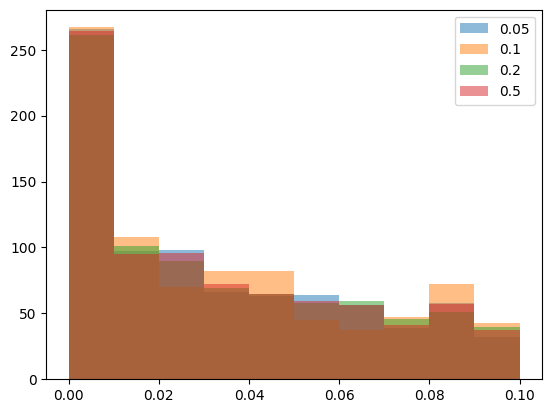

In [45]:
for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,0.1), alpha=0.5, label=str(label))
plt.legend()
plt.show()